# Tech Challenge 2 - Machine Learning

**O problema**

Você foi recentemente alocado em uma equipe de cientistas de dados de um grande fundo de investimentos brasileiro. Sua missão inicial é desenvolver um modelo preditivo capaz de prever se o índice IBOVESPA vai fechar em alta ou baixa no dia seguinte, com base em dados históricos do próprio índice. Esse modelo será usado como insumo para alimentar dashboards internos de tomada de decisão dos analistas quantitativos da empresa.

**Dados**

Utilize os dados históricos do índice IBOVESPA e:

*   Selecione o período “diário”.
*   Baixe um intervalo de pelo menos 2 anos de dados.
*   Realize o pré-processamento necessário para utilizar os dados no modelo.

**Objetivo**

Criar um modelo que preveja se o fechamento do IBOVESPA do dia seguinte será maior ou menor que o do dia atual.

Seu modelo deve prever a tendência (↑ ou ↓) com acuracidade mínima de 75% em um conjunto de teste. O conjunto de testes deverá conter o último mês (30 dias) de dados disponíveis.

## Importando Bibliotecas

In [1]:
!pip install statsforecast

In [2]:
pip install neuralprophet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import yfinance as yf

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, SeasonalWindowAverage, AutoARIMA
from statsforecast.utils import ConformalIntervals

In [8]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

In [9]:
from neuralprophet import NeuralProphet

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [10]:
df = yf.download('^BVSP', start='2008-01-01', end='2025-07-01', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [11]:
df = df[['Close', "High", "Low", "Open", "Volume"]].dropna().reset_index()
df.columns = ['Data', 'Fechamento', 'Alta', 'Baixa', 'Abertura', 'Volume']

In [12]:
df.head(2)

,Data,Fechamento,Alta,Baixa,Abertura,Volume
0,2008-01-02,62815.0,63906.0,62659.0,63885.0,2980200
1,2008-01-03,62892.0,63129.0,62556.0,62814.0,1895800


In [13]:
df.tail(2)

,Data,Fechamento,Alta,Baixa,Abertura,Volume
4330,2025-06-27,136866.0,137209.0,136469.0,137113.0,6244500
4331,2025-06-30,138855.0,139103.0,136430.0,136865.0,7680300


## Tratamento dos Dados

In [14]:
df.isnull().sum()

,0
Data,0
Fechamento,0
Alta,0
Baixa,0
Abertura,0
Volume,0


In [15]:
df.duplicated().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4332 entries, 0 to 4331
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        4332 non-null   datetime64[ns]
 1   Fechamento  4332 non-null   float64       
 2   Alta        4332 non-null   float64       
 3   Baixa       4332 non-null   float64       
 4   Abertura    4332 non-null   float64       
 5   Volume      4332 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 203.2 KB


In [17]:
df.shape

(4332, 6)

## Análise Exploratória

In [18]:
def EDA (df, y):
  ax = df.plot(x='Data', y=y, kind='line', label='Preço de ' + str(y))
  ax.set_title('Indíce IBOVESPA ' + str(y))
  ax.set_xlabel('Data')
  ax.set_ylabel('Preço')
  fig = ax.get_figure()
  fig.set_figwidth(15)
  fig.set_figheight(5)
  plt.show()

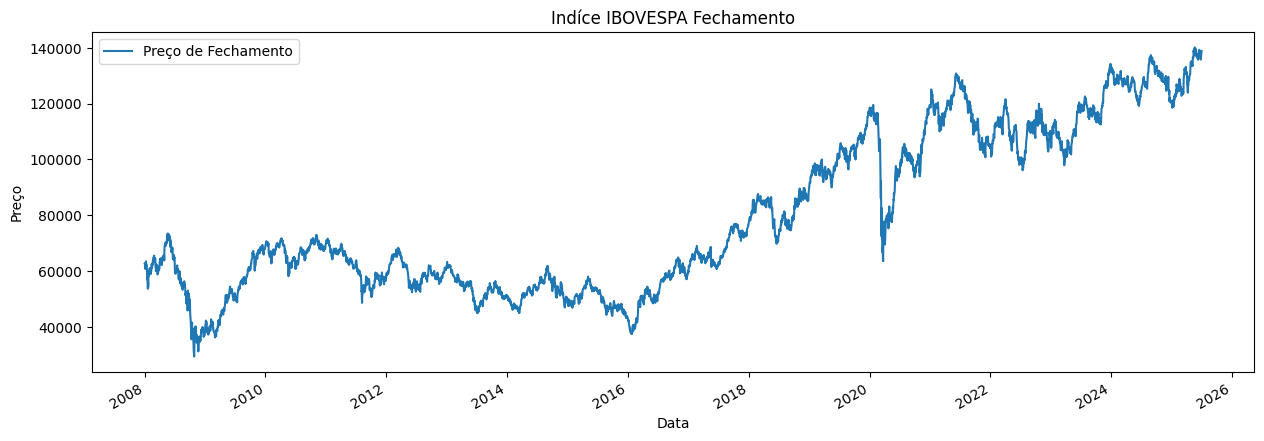

In [19]:
EDA(df,'Fechamento')

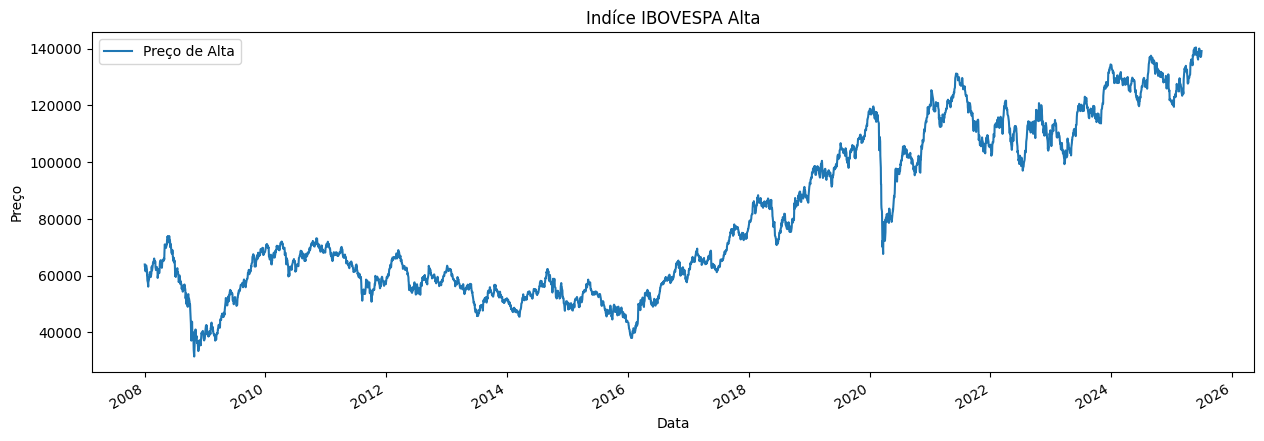

In [20]:
EDA(df,'Alta')

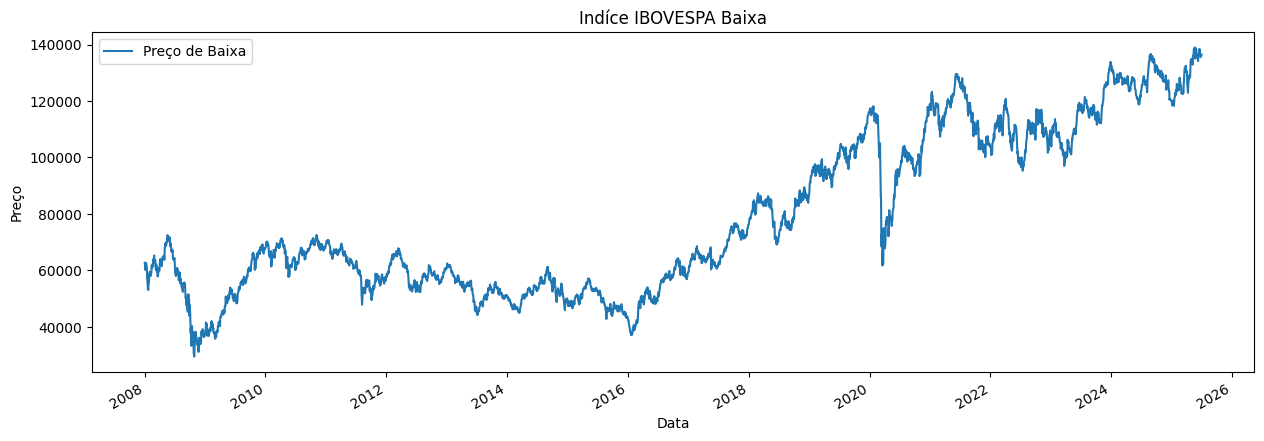

In [21]:
EDA(df,'Baixa')

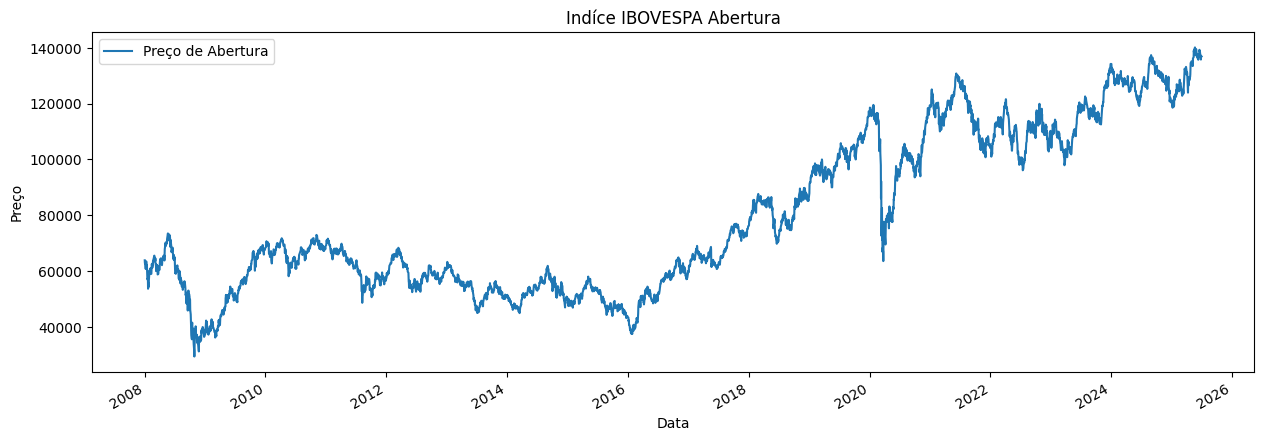

In [22]:
EDA(df,'Abertura')

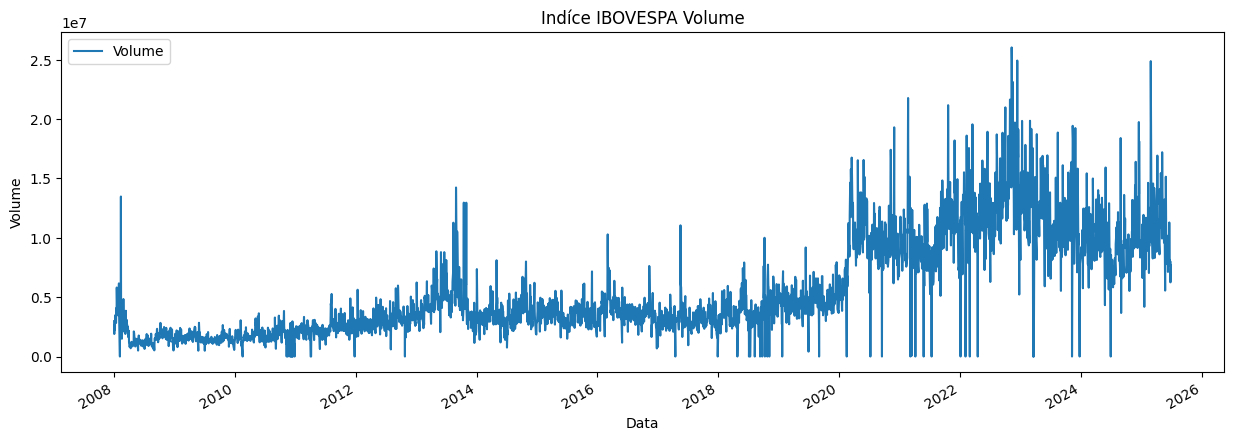

In [23]:
ax = df.plot(x='Data', y='Volume', kind='line', label='Volume')
ax.set_title('Indíce IBOVESPA Volume')
ax.set_xlabel('Data')
ax.set_ylabel('Volume')
fig = ax.get_figure()
fig.set_figwidth(15)
fig.set_figheight(5)
plt.show()

In [24]:
def EDA_Time(df, y):
  colunas_tirar = [col for col in df.columns if col != y and col != 'Data']
  df_close = df.set_index('Data')
  df_close = df_close.drop(colunas_tirar, axis=1)
  resultados = seasonal_decompose(df_close, period=1)
  fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize = (15,10))
  resultados.observed.plot(ax=ax1)
  resultados.trend.plot(ax=ax2)
  resultados.seasonal.plot(ax=ax3)
  resultados.resid.plot(ax=ax4)
  plt.tight_layout()
  plot_acf(df_close[y])
  plot_pacf(df_close[y])
  plt.show()

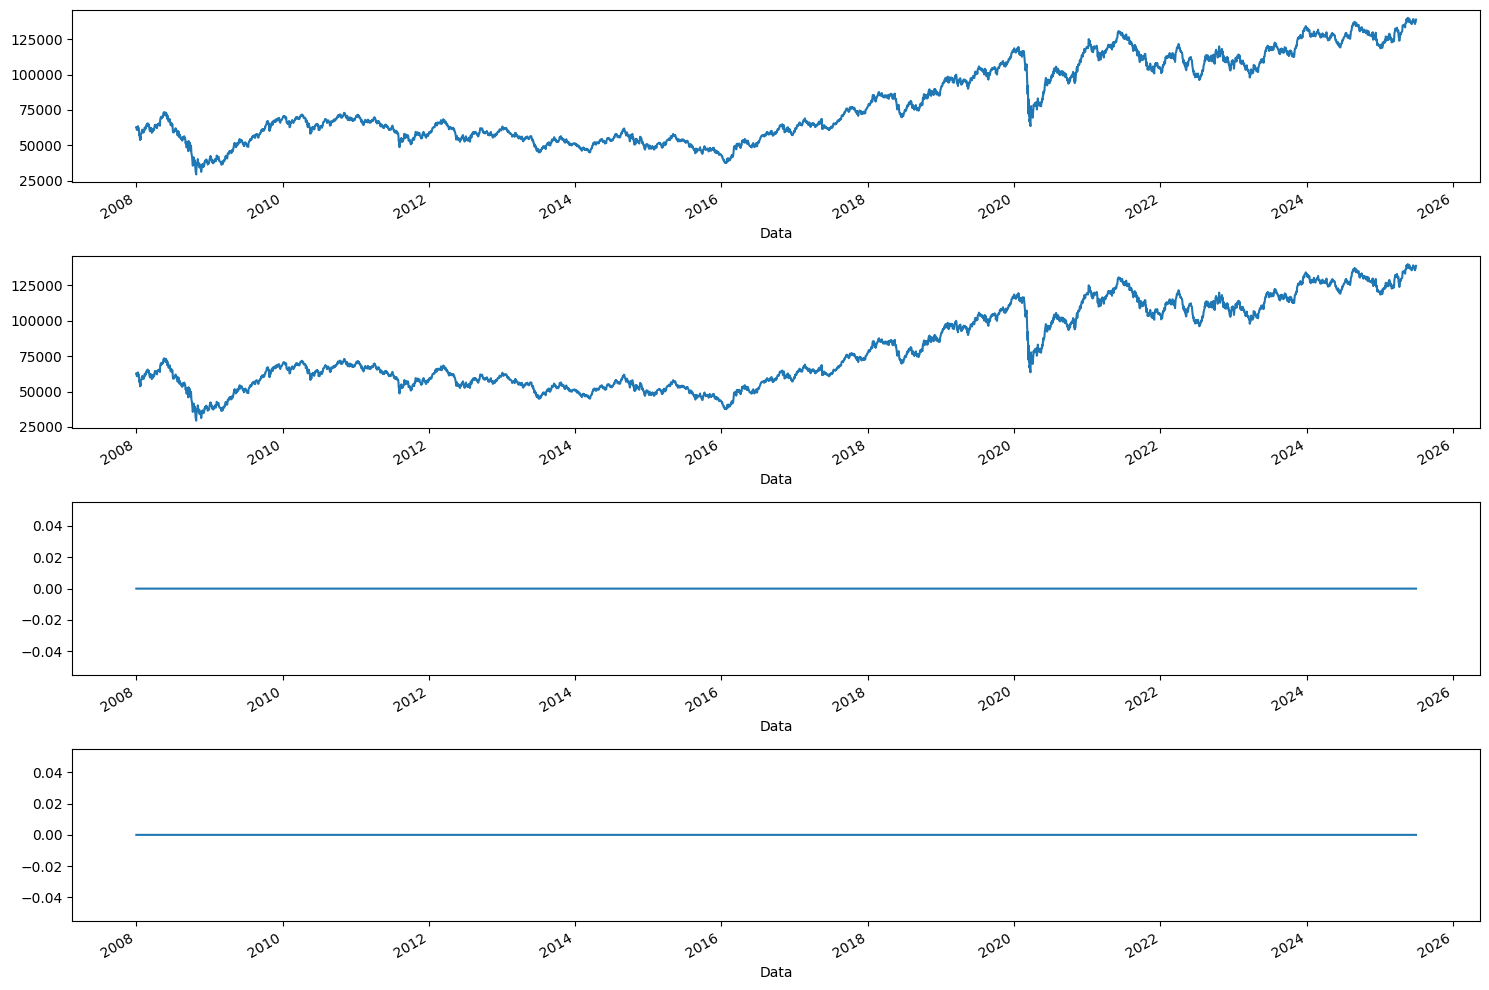

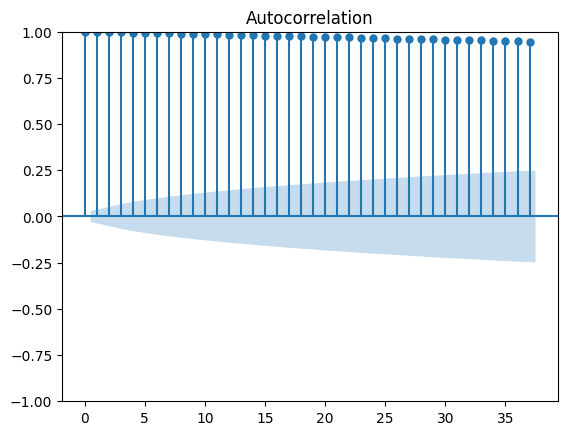

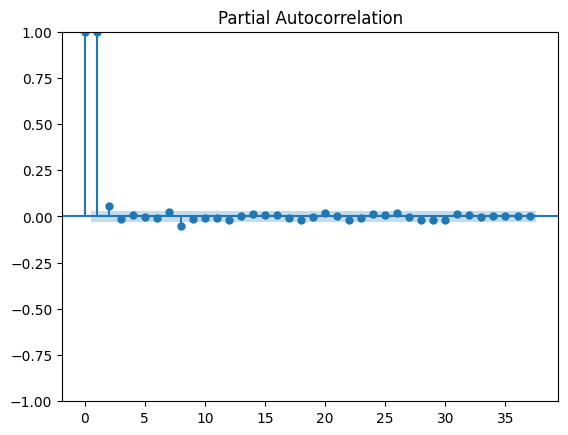

In [25]:
EDA_Time(df, 'Fechamento')

## Estacionariedade

In [26]:
def def_adf(df, y):
  colunas_tirar = [col for col in df.columns if col != y and col != 'Data']
  df_close = df.set_index('Data')
  df_close = df_close.drop(colunas_tirar, axis=1)

  X = df_close[y]
  result = adfuller(X)

  print("Teste ADF")
  print(f"Teste Estatístico: {result[0]}")
  print(f"P-Value: {result[1]}")
  print("Valores críticos:")

  if result[1] > 0.05:
    print("Não é estacionária")
  else:
    print("Estacionária")

  for key, value in result[4].items():
    print(f"\t{key}: {value}")

  df_puro = df_close
  return df_puro

In [27]:
def def_adf_ma(df, y, ma):
  colunas_tirar = [col for col in df.columns if col != y and col != 'Data']
  df_close = df.set_index('Data')
  df_close = df_close.drop(colunas_tirar, axis=1)

  df_close = df_close.rolling(ma).mean()
  X = df_close[y].dropna()
  result = adfuller(X)

  print("Teste ADF")
  print(f"Teste Estatístico: {result[0]}")
  print(f"P-Value: {result[1]}")
  print("Valores críticos:")

  if result[1] > 0.05:
    print("Não é estacionária")
  else:
    print("Estacionária")

  for key, value in result[4].items():
    print(f"\t{key}: {value}")

  df_ma = df_close.dropna()
  return df_ma

In [28]:
def def_adf_log(df, y, ma):
  colunas_tirar = [col for col in df.columns if col != y and col != 'Data']
  df_close = df.set_index('Data')
  df_close = df_close.drop(colunas_tirar, axis=1)

  df_log = np.log(df_close)
  ma_log = df_log.rolling(ma).mean()

  df_s = (df_log - ma_log).dropna()
  ma_s = df_s.rolling(ma).mean()
  std_s = df_s.rolling(ma).std()

  X = df_s[y]
  result = adfuller(X)

  print("Teste ADF")
  print(f"Teste Estatístico: {result[0]}")
  print(f"P-Value: {result[1]}")
  print("Valores críticos:")

  if result[1] > 0.05:
    print("Não é estacionária")
  else:
    print("Estacionária")

  for key, value in result[4].items():
    print(f"\t{key}: {value}")

  df_log = df_s.dropna()
  return df_log

In [29]:
def def_adf_diff(df, y, ma, diff):
  colunas_tirar = [col for col in df.columns if col != y and col != 'Data']
  df_close = df.set_index('Data')
  df_close = df_close.drop(colunas_tirar, axis=1)

  df_log = np.log(df_close)
  ma_log = df_log.rolling(ma).mean()

  df_s = (df_log - ma_log).dropna()

  df_diff = df_s.diff(diff)
  ma_diff = df_diff.rolling(ma).mean()
  std_diff = df_diff.rolling(ma).std()

  X = df_s[y]
  result = adfuller(X)

  print("Teste ADF")
  print(f"Teste Estatístico: {result[0]}")
  print(f"P-Value: {result[1]}")
  print("Valores críticos:")

  if result[1] > 0.05:
    print("Não é estacionária")
  else:
    print("Estacionária")

  for key, value in result[4].items():
    print(f"\t{key}: {value}")

  df_diff = df_diff.dropna()
  return df_diff

In [30]:
def frames(df, y, ma, diff):
  print('='*40)
  print('Dados Puros')
  df_puro = def_adf(df, y)
  print('='*40)
  print('Dados com Médias Móveis')
  df_ma = def_adf_ma(df, y, ma)
  print('='*40)
  print('Dados transformados por Logaritimo')
  df_log = def_adf_log(df, y, ma)
  print('='*40)
  print('Dados transformados com Diferenciação')
  df_diff = def_adf_diff(df, y, ma, diff)
  print('='*40)
  return df_puro, df_ma, df_log, df_diff
  print('df_puro, df_ma, df_log e df_diff armazenados')

In [31]:
df_puro, df_ma, df_log, df_diff = frames(df, 'Fechamento', 12, 1)

Dados Puros
Teste ADF
Teste Estatístico: -0.6576217890565506
P-Value: 0.8574232884506701
Valores críticos:
Não é estacionária
	1%: -3.4318635755729954
	5%: -2.862208813683775
	10%: -2.567126014291058
Dados com Médias Móveis
Teste ADF
Teste Estatístico: -0.8432361844873452
P-Value: 0.806090807554244
Valores críticos:
Não é estacionária
	1%: -3.4318752254397578
	5%: -2.862213960168296
	10%: -2.5671287540276353
Dados transformados por Logaritimo
Teste ADF
Teste Estatístico: -12.213841722959328
P-Value: 1.1475304691830824e-22
Valores críticos:
Estacionária
	1%: -3.4318713222755868
	5%: -2.8622122358955395
	10%: -2.5671278361087952
Dados transformados com Diferenciação
Teste ADF
Teste Estatístico: -12.213841722959328
P-Value: 1.1475304691830824e-22
Valores críticos:
Estacionária
	1%: -3.4318713222755868
	5%: -2.8622122358955395
	10%: -2.5671278361087952


In [32]:
df_ma

,Fechamento
Data,
2008-01-17,61303.083333
2008-01-18,60860.666667
2008-01-21,60095.416667
2008-01-22,59683.750000
2008-01-23,59139.000000
...,...
2025-06-24,137335.250000
2025-06-25,137307.333333
2025-06-26,137425.250000


## Criação dos Modelos

In [33]:
def wmape(y_true, y_pred):
  return np.abs(y_true-y_pred).sum() / np.abs(y_true).sum()

In [34]:
def modelos(df, y, length, window):
  df_1 = df.copy()
  df_1.reset_index(inplace=True)
  df_1 = df_1.rename(columns={'Data':'ds', y:'y'})

  treino = df_1[:-43]
  valid = df_1[-43:]
  h = valid['ds'].nunique()
  i = treino['ds'].nunique()
  treino['unique_id'] = 'serie1'
  valid['unique_id'] = 'serie1'

  modelo = StatsForecast(models=[Naive(), SeasonalNaive(season_length=length),
                                 SeasonalWindowAverage(season_length=length, window_size=window,  prediction_intervals=ConformalIntervals(n_windows=30)),
                                 AutoARIMA(season_length=length)],
                          freq='D', n_jobs=-1)
  modelo.fit(treino)

  forecast_df = modelo.predict(h=h, level=[90])
  forecast_df = forecast_df.reset_index(drop=True).merge(valid, on=['ds', 'unique_id'], how='left')
  forecast_df = forecast_df.dropna()

  wmape1 = wmape(forecast_df['y'].values, forecast_df['Naive'].values)
  wmape2 = wmape(forecast_df['y'].values, forecast_df['SeasonalNaive'].values)
  wmape3 = wmape(forecast_df['y'].values, forecast_df['SeasWA'].values)
  wmape4 = wmape(forecast_df['y'].values, forecast_df['AutoARIMA'].values)
  all_wmape = [wmape1, wmape2, wmape3, wmape4]

  grafico = modelo.plot(treino, forecast_df, level=[90], unique_ids=['serie1'], engine ='matplotlib', max_insample_length=90)
  return grafico, forecast_df, all_wmape

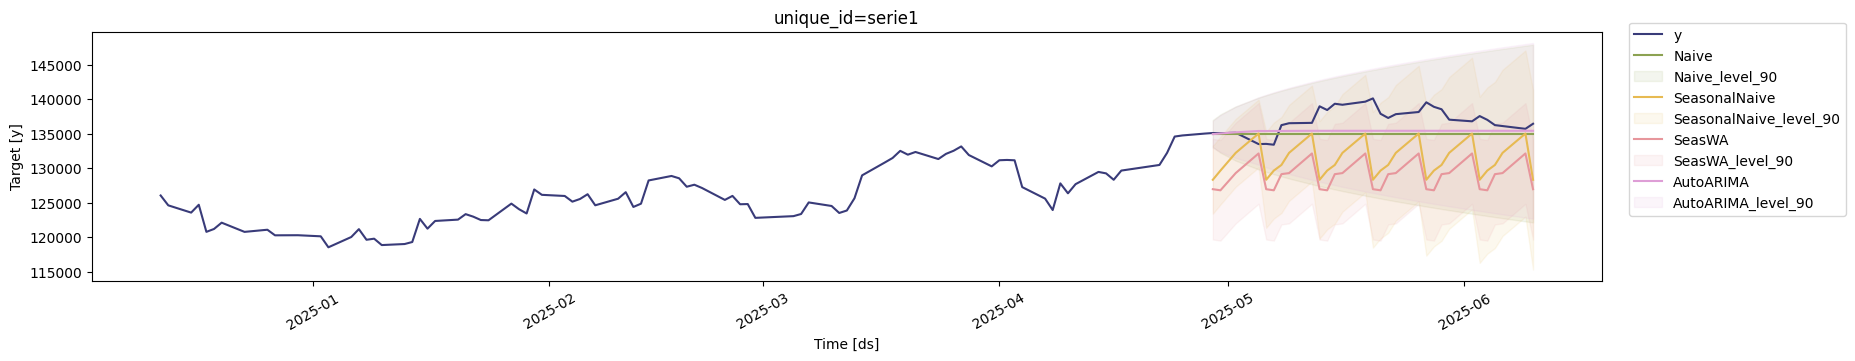

In [35]:
grafico_puro, forecast_df_puro, all_wmape_puro = modelos(df_puro, 'Fechamento', 7, 2)
grafico_puro

In [36]:
print("WMAPE Puro:")
print(f"Naive {all_wmape_puro[0]:.2%}")
print(f"SeasonalNaive: {all_wmape_puro[1]:.2%}")
print(f"SeasonalWindowAverage {all_wmape_puro[2]:.2%}")
print(f"AutoARIMA {all_wmape_puro[3]:.2%}")

WMAPE Puro:
Naive 1.71%
SeasonalNaive: 4.45%
SeasonalWindowAverage 6.03%
AutoARIMA 1.51%


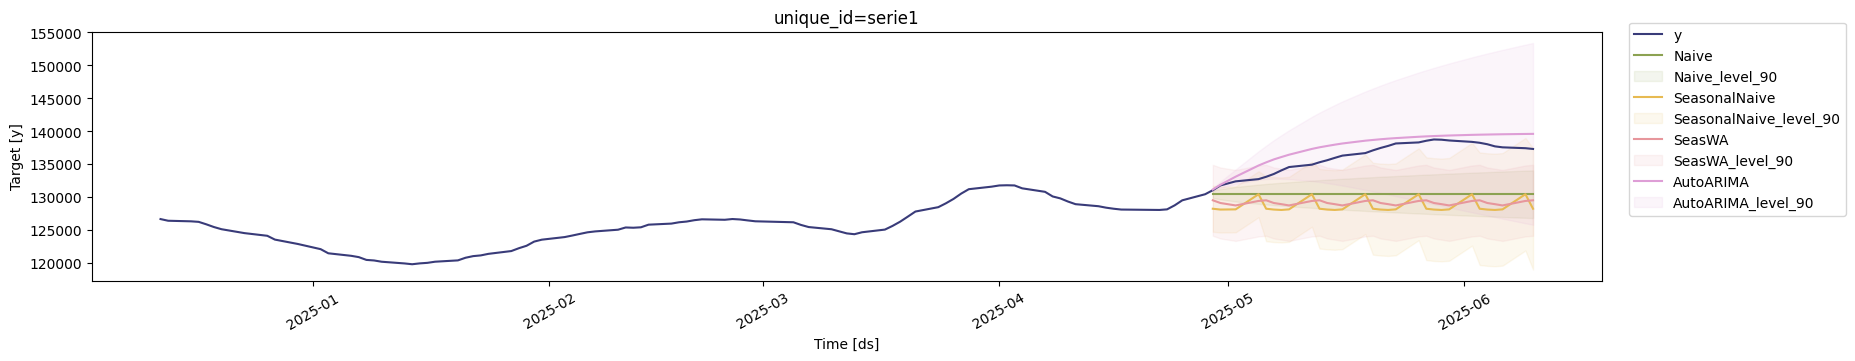

In [37]:
grafico_ma, forecast_df_ma, all_wmape_ma = modelos(df_ma, 'Fechamento', 7, 2)
grafico_ma

In [38]:
print("WMAPE Médias Móveis:")
print(f"Naive {all_wmape_ma[0]:.2%}")
print(f"SeasonalNaive: {all_wmape_ma[1]:.2%}")
print(f"SeasonalWindowAverage {all_wmape_ma[2]:.2%}")
print(f"AutoARIMA {all_wmape_ma[3]:.2%}")

WMAPE Médias Móveis:
Naive 4.23%
SeasonalNaive: 5.57%
SeasonalWindowAverage 5.16%
AutoARIMA 1.08%


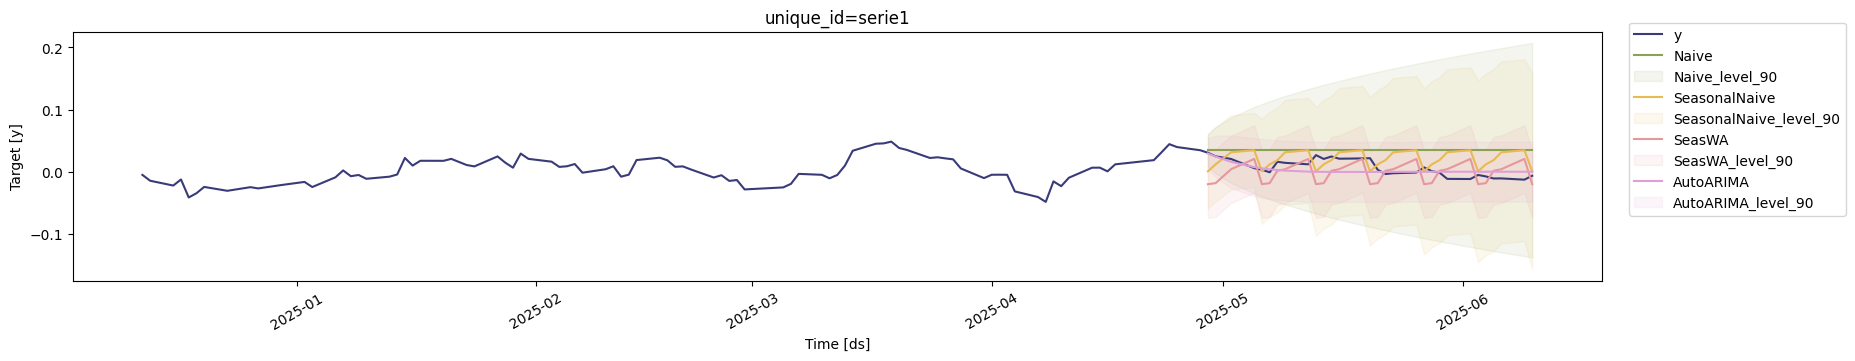

In [39]:
grafico_log, forecast_df_log, all_wmape_log = modelos(df_log, 'Fechamento', 7, 2)
grafico_log

In [40]:
print("WMAPE Logaritimo:")
print(f"Naive {all_wmape_log[0]:.2%}")
print(f"SeasonalNaive: {all_wmape_log[1]:.2%}")
print(f"SeasonalWindowAverage {all_wmape_log[2]:.2%}")
print(f"AutoARIMA {all_wmape_log[3]:.2%}")

WMAPE Logaritimo:
Naive 235.89%
SeasonalNaive: 167.56%
SeasonalWindowAverage 171.72%
AutoARIMA 79.51%


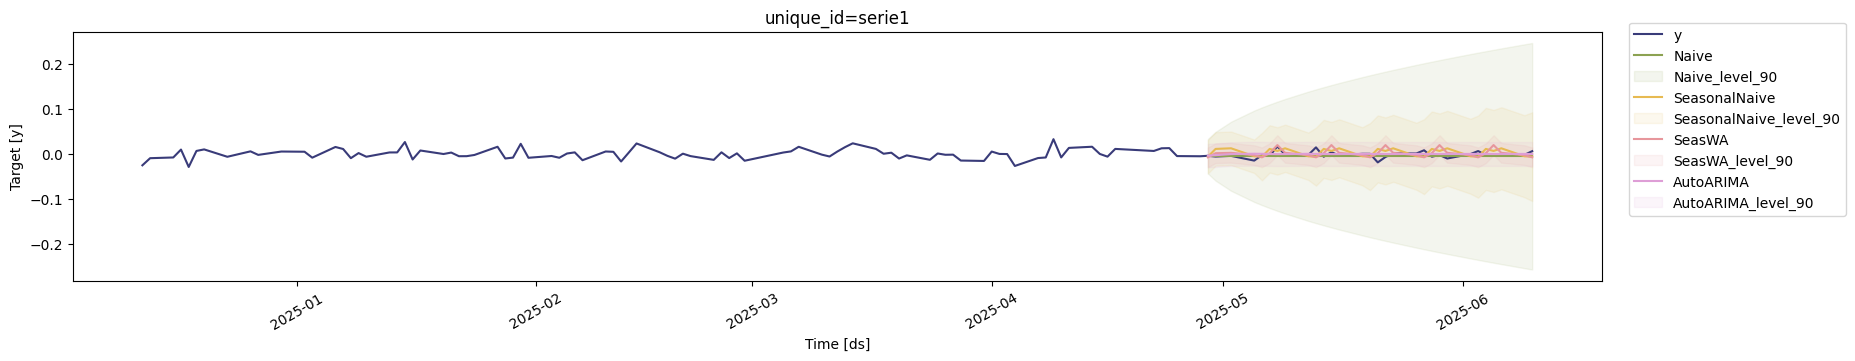

In [41]:
grafico_diff, forecast_df_diff, all_wmape_diff = modelos(df_diff, 'Fechamento', 7, 2)
grafico_diff

In [42]:
print("WMAPE Diferenciação:")
print(f"Naive {all_wmape_diff[0]:.2%}")
print(f"SeasonalNaive: {all_wmape_diff[1]:.2%}")
print(f"SeasonalWindowAverage {all_wmape_diff[2]:.2%}")
print(f"AutoARIMA {all_wmape_diff[3]:.2%}")

WMAPE Diferenciação:
Naive 109.94%
SeasonalNaive: 219.89%
SeasonalWindowAverage 174.94%
AutoARIMA 96.25%


In [43]:
def classificar(row, modelo):
    if row['y'] == 'Aumentou' and row[modelo] == 'Aumentou':
        return 'TP'
    elif row['y'] == 'Aumentou' and row[modelo] == 'Diminuiu':
        return 'FN'
    elif row['y'] == 'Diminuiu' and row[modelo] == 'Aumentou':
        return 'FP'
    elif row['y'] == 'Diminuiu' and row[modelo] == 'Diminuiu':
        return 'TN'
    else:
        return 'Indefinido'

In [44]:
def calcular_acuracia(df, modelo):
    tp = df[df[f'{modelo}_Class'] == 'TP'].shape[0]
    tn = df[df[f'{modelo}_Class'] == 'TN'].shape[0]
    fp = df[df[f'{modelo}_Class'] == 'FP'].shape[0]
    fn = df[df[f'{modelo}_Class'] == 'FN'].shape[0]

    total = tp + tn + fp + fn
    if total == 0:
        return 0
    return (tp + tn) / total

In [45]:
def acuracia(df, forecast_df, y):
  data_inical = forecast_df['ds'].iloc[0]
  dia_antes = df.iloc[df.index.get_loc(data_inical) -1].name
  valor_antes = df.iloc[df.index.get_loc(data_inical) - 1][y]

  referencia = {'ds': pd.Timestamp(dia_antes), 'unique_id': 'serie1',  'y': valor_antes,
              'Naive': valor_antes, 'Naive-lo-90': valor_antes, 'Naive-hi-90': valor_antes,
              'SeasonalNaive': valor_antes, 'SeasonalNaive-lo-90': valor_antes, 'SeasonalNaive-hi-90': valor_antes,
              'SeasWA': valor_antes, 'SeasWA-lo-90': valor_antes, 'SeasWA-hi-90': valor_antes,
              'AutoARIMA': valor_antes, 'AutoARIMA-lo-90': valor_antes, 'AutoARIMA-hi-90': valor_antes}

  forecast_df = pd.concat([pd.DataFrame([referencia]), forecast_df], ignore_index=True)
  forecast_df.sort_values('ds', inplace=True)
  forecast_df.reset_index(drop=True, inplace=True)

  colunas = ['y', 'Naive', 'SeasonalNaive', 'SeasWA', 'AutoARIMA']
  diferencas = forecast_df[colunas].diff()
  resultado = pd.concat([forecast_df['ds'], diferencas], axis=1).dropna()

  comparacoes = resultado[['ds']].copy()

  for col in colunas:
    comparacoes[col + '_variação'] = resultado[col].apply(
        lambda x: 'Aumentou' if x > 0 else 'Diminuiu')

  comparacoes.columns = ['ds', 'y', 'Naive', 'SeasonalNaive', 'SeasWA', 'AutoARIMA']

  modelos = ['Naive', 'SeasonalNaive', 'SeasWA', 'AutoARIMA']

  for modelo in modelos:
    comparacoes[f'{modelo}_Class'] = comparacoes.apply(lambda row: classificar(row, modelo), axis=1)

  for modelo in modelos:
    print(f'='*40)
    print(f'{modelo}:')
    acuracia = calcular_acuracia(comparacoes, modelo)
    print(f'Acurácia do modelo {modelo}: {acuracia:.2f}')
    print(comparacoes[f'{modelo}_Class'].value_counts())

In [46]:
acuracia(df_puro, forecast_df_puro, 'Fechamento')

Naive:
Acurácia do modelo Naive: 0.50
Naive_Class
FN    15
TN    15
Name: count, dtype: int64
SeasonalNaive:
Acurácia do modelo SeasonalNaive: 0.27
SeasonalNaive_Class
FP    15
TP     8
FN     7
Name: count, dtype: int64
SeasWA:
Acurácia do modelo SeasWA: 0.47
SeasWA_Class
FP    9
TP    8
FN    7
TN    6
Name: count, dtype: int64
AutoARIMA:
Acurácia do modelo AutoARIMA: 0.27
AutoARIMA_Class
FP    15
TP     8
FN     7
Name: count, dtype: int64


In [47]:
acuracia(df_ma, forecast_df_ma, 'Fechamento')

Naive:
Acurácia do modelo Naive: 0.30
Naive_Class
FN    21
TN     9
Name: count, dtype: int64
SeasonalNaive:
Acurácia do modelo SeasonalNaive: 0.43
SeasonalNaive_Class
FN    13
TP     8
TN     5
FP     4
Name: count, dtype: int64
SeasWA:
Acurácia do modelo SeasWA: 0.43
SeasWA_Class
FN    13
TP     8
TN     5
FP     4
Name: count, dtype: int64
AutoARIMA:
Acurácia do modelo AutoARIMA: 0.70
AutoARIMA_Class
TP    21
FP     9
Name: count, dtype: int64


In [48]:
acuracia(df_log, forecast_df_log, 'Fechamento')

Naive:
Acurácia do modelo Naive: 0.63
Naive_Class
TN    19
FN    11
Name: count, dtype: int64
SeasonalNaive:
Acurácia do modelo SeasonalNaive: 0.27
SeasonalNaive_Class
FP    17
TP     6
FN     5
TN     2
Name: count, dtype: int64
SeasWA:
Acurácia do modelo SeasWA: 0.27
SeasWA_Class
FP    17
TP     6
FN     5
TN     2
Name: count, dtype: int64
AutoARIMA:
Acurácia do modelo AutoARIMA: 0.60
AutoARIMA_Class
TN    11
FP     8
TP     7
FN     4
Name: count, dtype: int64


In [49]:
acuracia(df_diff, forecast_df_diff, 'Fechamento')

Naive:
Acurácia do modelo Naive: 0.50
Naive_Class
FN    15
TN    15
Name: count, dtype: int64
SeasonalNaive:
Acurácia do modelo SeasonalNaive: 0.30
SeasonalNaive_Class
FN    12
FP     9
TN     6
TP     3
Name: count, dtype: int64
SeasWA:
Acurácia do modelo SeasWA: 0.43
SeasWA_Class
FN    10
TN     8
FP     7
TP     5
Name: count, dtype: int64
AutoARIMA:
Acurácia do modelo AutoARIMA: 0.43
AutoARIMA_Class
FN    9
FP    8
TN    7
TP    6
Name: count, dtype: int64


In [102]:
def profetas(df, y):
  df_1 = df.copy()
  df_1.reset_index(inplace=True)
  df_1 = df_1.rename(columns={'Data':'ds', y:'y'})

  treino = df_1[:-30]
  valid = df_1[-30:]
  h = valid['ds'].nunique()
  i = treino['ds'].nunique()
  treino['unique_id'] = 'serie1'
  valid['unique_id'] = 'serie1'

  np.random.seed(4587)

  modelo = Prophet()
  modelo.fit(treino)

  previsao = modelo.predict(valid)
  forecast_df_pro = previsao[['ds', 'yhat_lower', 'yhat_upper','yhat']]

  forecast_df_pro = forecast_df_pro.reset_index(drop=True).merge(valid, on=['ds'], how='left')

  wmape_pro = wmape(forecast_df_pro['y'].values, forecast_df_pro['yhat'].values)

  return modelo, forecast_df_pro, wmape_pro

In [103]:
modelo_puro_pro, forecast_df_puro_pro, wmape_puro_pro = profetas(df_puro, 'Fechamento')
modelo_ma_pro, forecast_df_ma_pro, wmape_ma_pro = profetas(df_ma, 'Fechamento')
modelo_log_pro, forecast_df_log_pro, wmape_log_pro = profetas(df_log, 'Fechamento')
modelo_diff_pro, forecast_df_diff_pro, wmape_diff_pro = profetas(df_diff, 'Fechamento')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsaxg54he/k59tsqkk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsaxg54he/dd6muymp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52520', 'data', 'file=/tmp/tmpsaxg54he/k59tsqkk.json', 'init=/tmp/tmpsaxg54he/dd6muymp.json', 'output', 'file=/tmp/tmpsaxg54he/prophet_modelcxsk_j87/prophet_model-20250802194926.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:49:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:49:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsa

(80000.0, 140000.0)

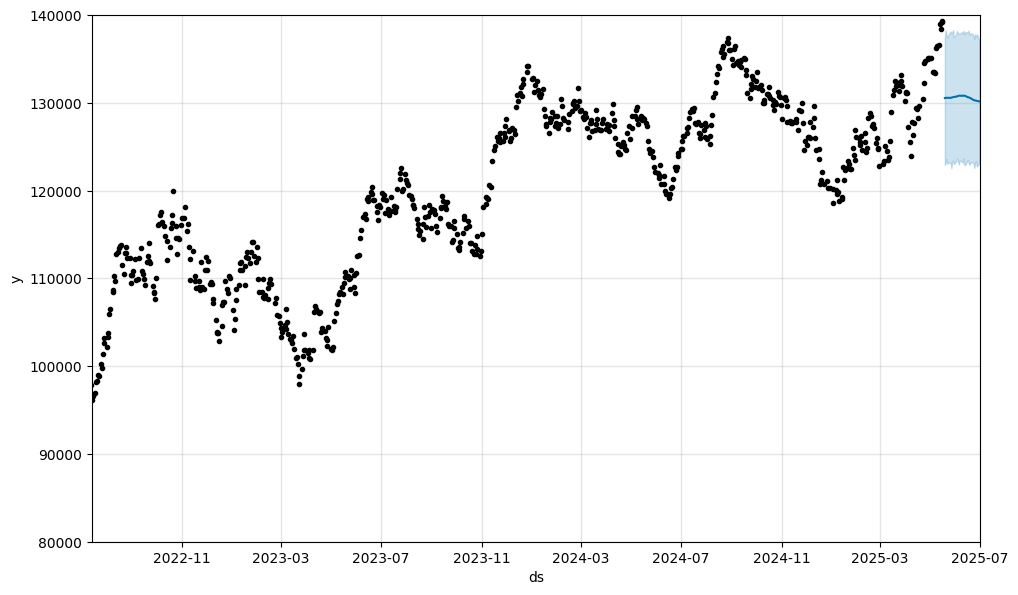

In [104]:
  fig = modelo_puro_pro.plot(forecast_df_puro_pro.dropna())
  ax  = fig.gca()

  data_inicio = pd.to_datetime(forecast_df_puro_pro['ds'].min()) - pd.Timedelta(days=1040)
  data_fim    = pd.to_datetime(forecast_df_puro_pro['ds'].max()) + pd.Timedelta(days=1)

  ax.set_xlim(data_inicio, data_fim)
  ax.set_ylim(80000, 140000)

(80000.0, 140000.0)

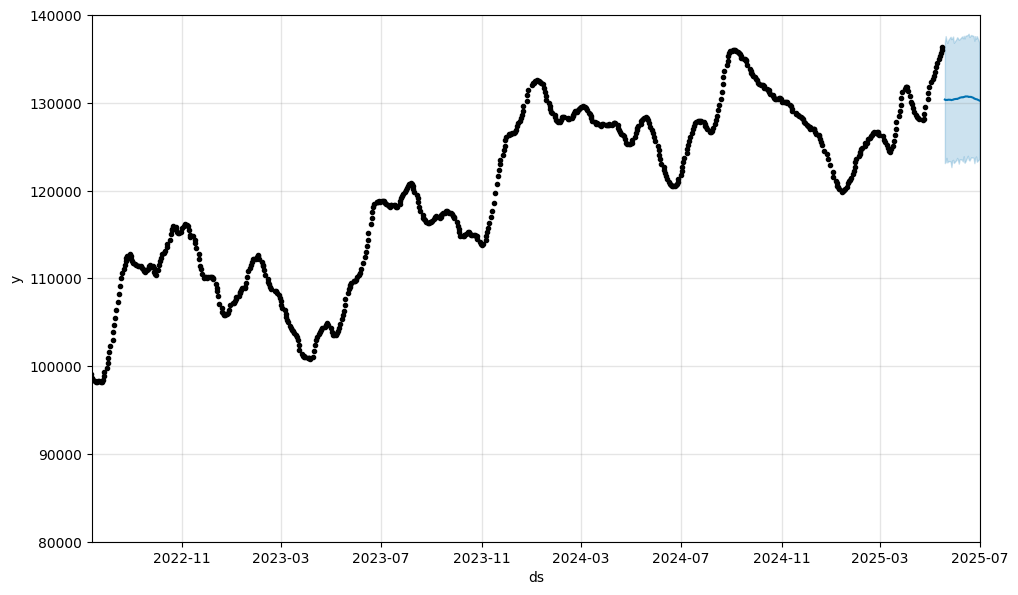

In [105]:
  fig = modelo_ma_pro.plot(forecast_df_ma_pro.dropna())
  ax  = fig.gca()

  data_inicio = pd.to_datetime(forecast_df_ma_pro['ds'].min()) - pd.Timedelta(days=1040)
  data_fim    = pd.to_datetime(forecast_df_ma_pro['ds'].max()) + pd.Timedelta(days=1)

  ax.set_xlim(data_inicio, data_fim)
  ax.set_ylim(80000, 140000)

(-0.1, 0.1)

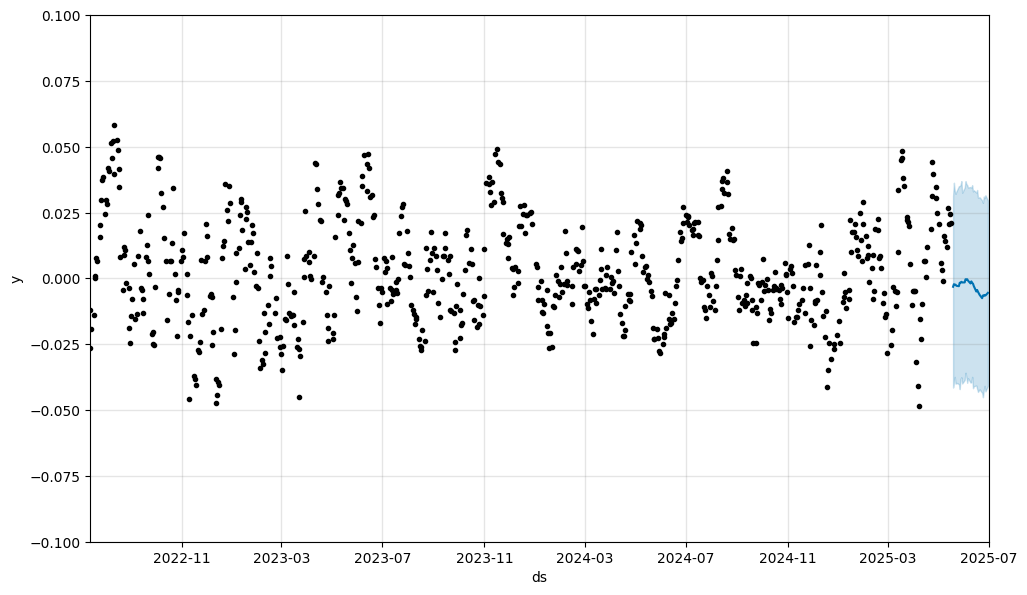

In [108]:
  fig = modelo_log_pro.plot(forecast_df_log_pro.dropna())
  ax  = fig.gca()

  data_inicio = pd.to_datetime(forecast_df_log_pro['ds'].min()) - pd.Timedelta(days=1040)
  data_fim    = pd.to_datetime(forecast_df_log_pro['ds'].max()) + pd.Timedelta(days=1)

  ax.set_xlim(data_inicio, data_fim)
  ax.set_ylim(-0.10, 0.10)

(-0.1, 0.1)

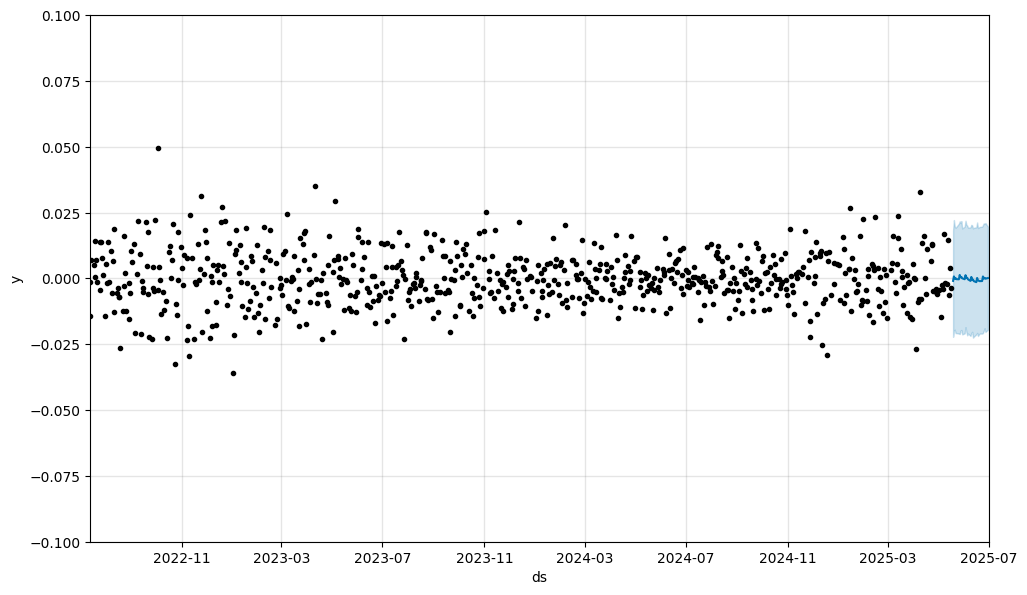

In [109]:
  fig = modelo_diff_pro.plot(forecast_df_diff_pro.dropna())
  ax  = fig.gca()

  data_inicio = pd.to_datetime(forecast_df_diff_pro['ds'].min()) - pd.Timedelta(days=1040)
  data_fim    = pd.to_datetime(forecast_df_diff_pro['ds'].max()) + pd.Timedelta(days=1)

  ax.set_xlim(data_inicio, data_fim)
  ax.set_ylim(-0.10, 0.10)

In [110]:
print("WMAPE Prophet:")
print(f"Puro {wmape_puro_pro:.2%}")
print(f"Médias Móveis: {wmape_ma_pro:.2%}")
print(f"Logaritimo {wmape_log_pro:.2%}")
print(f"Diferenciado {wmape_diff_pro:.2%}")

WMAPE Prophet:
Puro 5.12%
Médias Móveis: 5.21%
Logaritimo 109.55%
Diferenciado 98.01%


In [113]:
forecast_df_diff_pro

,ds,yhat_lower,yhat_upper,yhat,y,unique_id
0,2025-05-19,-0.022217,0.018188,-0.000957,0.000448,serie1
1,2025-05-20,-0.019991,0.022138,0.000733,0.000375,serie1
2,2025-05-21,-0.019487,0.019725,-0.000100,-0.018733,serie1
3,2025-05-22,-0.020804,0.019230,0.000092,-0.006732,serie1
4,2025-05-23,-0.020796,0.019570,-0.000311,0.001286,serie1
5,2025-05-26,-0.020989,0.020744,-0.000356,0.001105,serie1
6,2025-05-27,-0.021133,0.021676,0.001292,0.008291,serie1
7,2025-05-28,-0.019853,0.021025,0.000401,-0.006097,serie1
8,2025-05-29,-0.019604,0.021752,0.000519,-0.002294,serie1
9,2025-05-30,-0.021280,0.018942,0.000029,-0.010093,serie1


In [128]:
def acuracia_pro(df, forecast_df, y):
  data_inical = forecast_df['ds'].iloc[0]
  dia_antes = df.iloc[df.index.get_loc(data_inical) -1].name
  valor_antes = df.iloc[df.index.get_loc(data_inical) - 1][y]

  referencia = {'ds': pd.Timestamp(dia_antes), 'unique_id': 'serie1',  'y': valor_antes, 'yhat': valor_antes,
                'yhat_lower': valor_antes, 'yhat_upper': valor_antes}

  forecast_df = pd.concat([pd.DataFrame([referencia]), forecast_df], ignore_index=True)
  forecast_df.sort_values('ds', inplace=True)
  forecast_df.reset_index(drop=True, inplace=True)

  colunas = ['y', 'yhat']
  diferencas = forecast_df[colunas].diff()
  resultado = pd.concat([forecast_df['ds'], diferencas], axis=1).dropna()

  comparacoes = resultado[['ds']].copy()

  for col in colunas:
    comparacoes[col + '_variação'] = resultado[col].apply(
        lambda x: 'Aumentou' if x > 0 else 'Diminuiu')

  comparacoes.columns = ['ds', 'y', 'Prophet']

  modelos = ['Prophet']

  for modelo in modelos:
    comparacoes[f'{modelo}_Class'] = comparacoes.apply(lambda row: classificar(row, modelo), axis=1)

  for modelo in modelos:
    print(f'='*40)
    print(f'{modelo}:')
    acuracia = calcular_acuracia(comparacoes, modelo)
    print(f'Acurácia do modelo {modelo}: {acuracia:.2f}')
    print(comparacoes[f'{modelo}_Class'].value_counts())

In [131]:
datasets = [df_puro, df_ma, df_log, df_diff]
forecast_dfs = [forecast_df_puro_pro, forecast_df_ma_pro, forecast_df_log_pro, forecast_df_diff_pro]
nomes_datasets = ['Puro', 'Médias Móveis', 'Logaritimo', 'Diferenciado']

for dataset, forecast_df, nome  in zip(datasets, forecast_dfs, nomes_datasets):
  print(f'='*40)
  print(f'Dataset: {nome}')
  acuracia_pro(dataset, forecast_df, 'Fechamento')

Dataset: Puro
Prophet:
Acurácia do modelo Prophet: 0.47
Prophet_Class
TN    9
FN    8
FP    8
TP    5
Name: count, dtype: int64
Dataset: Médias Móveis
Prophet:
Acurácia do modelo Prophet: 0.30
Prophet_Class
FN    11
FP    10
TN     5
TP     4
Name: count, dtype: int64
Dataset: Logaritimo
Prophet:
Acurácia do modelo Prophet: 0.57
Prophet_Class
TN    10
FN     7
TP     7
FP     6
Name: count, dtype: int64
Dataset: Diferenciado
Prophet:
Acurácia do modelo Prophet: 0.73
Prophet_Class
TP    11
TN    11
FN     5
FP     3
Name: count, dtype: int64
